# Comparison of L2 (Least Squares) and Lasso Regression

This notebook demonstrates the difference between L2 and Lasso regression
in recovering sparse signals from noisy measurements. It shows how
Lasso regression can better recover sparse solutions compared to
standard least squares regression.

The setup involves:
1. Creating a sparse signal (x) with only two non-zero components
2. Generating noisy measurements (b) using a random measurement matrix (A)
3. Attempting to recover x using both L2 and Lasso regression

## Generating Synthetic Sparse Data

We create a true signal **x** with only two non-zero entries (sparse), then produce
noisy measurements **b = Ax + noise** using a random 100×10 measurement matrix.
The goal of both regression methods is to recover **x** from **A** and **b**.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

# Generate synthetic data
np.random.seed(0)  # For reproducibility
A = np.random.randn(100,10)  # Random measurement matrix
x = np.array([0, 0, 1, 0, 0, 0, -1, 0, 0, 0])  # True sparse signal
b = A @ x + np.random.randn(100)  # Noisy measurements

## L2 Regression (Least Squares)

The pseudoinverse minimises the L2 norm of the residual ‖Ax − b‖². It finds the minimum-norm
solution but does **not** promote sparsity, so "energy" tends to spread across all coefficients.

In [41]:
# Perform L2 regression (least squares)
xL2 = np.linalg.pinv(A) @ b  # Using pseudoinverse
print("L2 regression solution:")
print(xL2)  # Show L2 solution

L2 regression solution:
[ 0.01810637 -0.00766674  0.96745634  0.28963964 -0.1432013  -0.08593128
 -0.88883767  0.00395167  0.08238445 -0.10204504]


## Lasso Regression

Lasso adds an L1 penalty (α‖x‖₁) to the least-squares objective. The L1 penalty shrinks
small coefficients to exactly zero, effectively selecting only the most important features
and producing a sparse solution.

In [42]:
# Perform Lasso regression
reg = linear_model.Lasso(alpha=0.15).fit(A, b)
xLasso = reg.coef_  # Get Lasso coefficients
print("Lasso coefficients:")
print(xLasso)

Lasso coefficients:
[ 0.         -0.          0.78019046  0.14935785 -0.         -0.
 -0.66143821  0.          0.         -0.        ]


## Comparing Results

The bar plot shows the true signal alongside both recovered signals. Lasso should closely
match the true sparse signal, while L2 spreads the energy across all components.

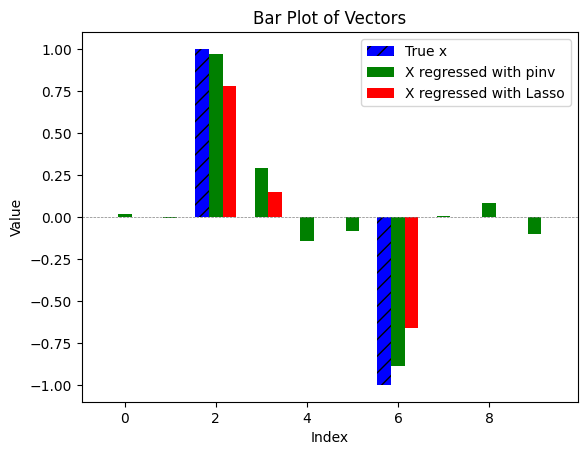

In [43]:
# Visualize results with bar plot
width = 0.3
positions = np.arange(len(x))

# Create comparative bar plot in one go with fixed offsets
plt.bar(positions - width, x, width=width, label='True x', color='blue', hatch='//')
plt.bar(positions, xL2, width=width, label='X regressed with pinv', color='green')
plt.bar(positions + width, xLasso, width=width, label='X regressed with Lasso', color='red')
plt.axhline(0, color='grey', linewidth=0.5, linestyle='--')  # Add horizontal line at y=0

plt.set_cmap("jet")
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Bar Plot of Vectors')
plt.legend()
plt.show()